# Sprint 1 - Job-Posting Corpus: Data Exploration

**Course:** IE7945 Workforce Analytics capstone - Sprint 1 ("assemble a shared job-posting corpus and agree on a data contract").

This notebook reads **only** `database/taxonomy.duckdb`, which `python run_pipeline.py` builds from preserved raw downloads.
Every number below is computed live from the database.

* **Empirical corpus:** public job postings (`job_postings`, raw records in `job_postings_raw`).
* **Reference taxonomies:** O\*NET (`onet_*`) and ESCO (`esco_*`). They are *not* mapped to postings in Sprint 1.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))
import duckdb, pandas as pd, matplotlib.pyplot as plt
from src.analysis.eda import style, BLUE, ORANGE, SOURCE_COLORS, INK, INK2, missingness, desc_stats
%matplotlib inline
pd.set_option('display.max_colwidth', 80); pd.set_option('display.width', 160)
con = duckdb.connect(str(ROOT / 'database' / 'taxonomy.duckdb'), read_only=True)
q = lambda sql: con.execute(sql).df()
plt.rcParams.update({'font.size': 10, 'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb'})
q("SELECT schema_name, table_name, estimated_size AS approx_rows FROM duckdb_tables() ORDER BY schema_name, table_name")

,schema_name,table_name,approx_rows
0,main,data_manifest,4
1,main,esco_occupation_hierarchy,3039
2,main,esco_occupation_skill_relations,126051
3,main,esco_occupations,3039
4,main,esco_skill_hierarchy,20183
5,main,esco_skills,13939
6,main,job_postings,5497
7,main,job_postings_raw,5595
8,main,onet_abilities,94640
9,main,onet_alternate_titles,54269


## 0. Sources and provenance
Every source, its version, licence/terms status, and whether it is final or a temporary bootstrap.

In [2]:
q('SELECT dataset_name, role, version, record_count, status, final_or_temporary FROM source_metadata')

,dataset_name,role,version,record_count,status,final_or_temporary
0,jobs_arbeitnow,empirical corpus,snapshot retrieval_20260925T052546Z,2800,OK - Temporary bootstrap source - instructor/team approval required before f...,TEMPORARY bootstrap - Temporary bootstrap source - instructor/team approval ...
1,jobs_nyc_jobs,empirical corpus,rowsUpdatedAt=1790103669,2795,OK - Temporary bootstrap source - instructor/team approval required before f...,TEMPORARY bootstrap - Temporary bootstrap source - instructor/team approval ...
2,esco_api_fallback,reference taxonomy,v1.2.1,3039 occupations; 13939 skills,OK (temporary API fallback),TEMPORARY - replace with official ESCO CSV package (manual download)
3,onet_database,reference taxonomy,31.0,45 csv files,OK,final (official reference)
4,esco_status,reference taxonomy,v1.2.1,NaN,ESCO_STATUS = MANUAL_DOWNLOAD_REQUIRED (official ZIP); TEMPORARY_API_FALLBAC...,api_fallback


## 1-5. Raw vs canonical vs unique postings, duplicates
* **raw** = records exactly as delivered by the source (`job_postings_raw`).
* **canonical** = one row per `posting_id` (identical source IDs repeated inside one snapshot collapsed).
* **unique** = distinct `normalized_dup_key` (normalized title + company + description). Duplicates are **flagged, never deleted**.

In [3]:
counts = q('''
SELECT (SELECT count(*) FROM job_postings_raw) AS raw_postings,
       count(*) AS canonical_postings,
       count(DISTINCT exact_dup_key) AS unique_exact,
       count(DISTINCT normalized_dup_key) AS unique_postings,
       sum(is_normalized_duplicate::INT) AS duplicate_count,
       round(100*avg(is_normalized_duplicate::INT),2) AS duplicate_pct
FROM job_postings''')
counts.T.rename(columns={0: 'value'})

,value
raw_postings,5595.00
canonical_postings,5497.00
unique_exact,4067.00
unique_postings,4029.00
duplicate_count,1468.00
duplicate_pct,26.71


In [4]:
q('''SELECT r.source, r.raw, c.canonical, c.unique_postings, c.duplicates, round(100*c.duplicates/c.canonical,2) AS dup_pct
FROM (SELECT source, count(*) raw FROM job_postings_raw GROUP BY 1) r
JOIN (SELECT source, count(*) canonical, count(DISTINCT normalized_dup_key) unique_postings,
             sum(is_normalized_duplicate::INT) duplicates FROM job_postings GROUP BY 1) c USING (source) ORDER BY 1''')

,source,raw,canonical,unique_postings,duplicates,dup_pct
0,arbeitnow,2800,2726,2625,101.0,3.71
1,nyc_jobs,2795,2771,1404,1367.0,49.33


**Why NYC has so many duplicates:** the City posts most vacancies twice - once *Internal* and once *External* - with the same Job ID and text. They are kept as separate canonical rows (different `source_job_id`) but share a `duplicate_group_id`.

In [5]:
q('''SELECT count(*) AS job_ids_posted_both_internal_and_external FROM (
       SELECT split_part(source_job_id,'-',1) jid FROM job_postings WHERE source='nyc_jobs'
       GROUP BY 1 HAVING count(DISTINCT split_part(source_job_id,'-',2)) = 2)''')

,job_ids_posted_both_internal_and_external
0,1324


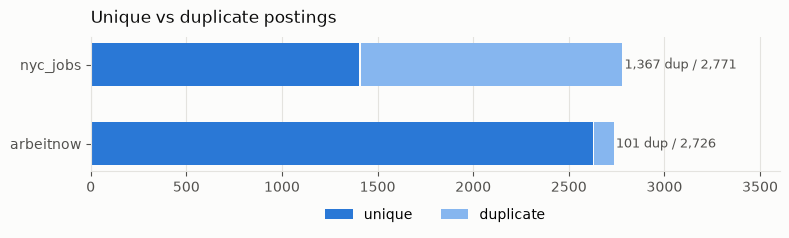

In [6]:
d = q('''SELECT source, count(DISTINCT normalized_dup_key) uniq, sum(is_normalized_duplicate::INT)::INTEGER dups FROM job_postings GROUP BY 1 ORDER BY 1''')
fig, ax = plt.subplots(figsize=(8, 2.6))
ax.barh(d.source, d.uniq, color=BLUE, height=0.55, label='unique')
ax.barh(d.source, d.dups, left=d.uniq + 8, color='#86b6ef', height=0.55, label='duplicate')
for y, (u, du) in enumerate(zip(d.uniq, d.dups)):
    ax.text(u + du + 20, y, f'{du:,} dup / {u+du:,}', va='center', color=INK2, fontsize=9)
ax.set_xlim(0, (d.uniq + d.dups).max() * 1.3)
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2); style(ax, 'Unique vs duplicate postings'); plt.tight_layout(); plt.show()

## 6. Missingness (share of NULL per canonical field, by source)
NULL means *not provided by the source* - nothing was imputed.

In [7]:
missingness(con)

source,arbeitnow,nyc_jobs
field,,
job_title,0.000,0.000
company_name,0.000,0.000
industry,1.000,1.000
industry_derived,1.000,0.000
location_raw,0.021,0.000
country,1.000,0.000
state,1.000,0.000
city,1.000,1.000
employment_type,0.321,0.000


## 7. Postings by source

In [8]:
q('SELECT source, count(*) postings, min(date_collected) collected FROM job_postings GROUP BY 1 ORDER BY 1')

,source,postings,collected
0,arbeitnow,2726,2026-09-25
1,nyc_jobs,2771,2026-09-25


## 8. Top job titles (unique postings, normalized titles)

In [9]:
q('''SELECT source, normalized_job_title, count(*) n FROM job_postings_unique GROUP BY ALL ORDER BY n DESC LIMIT 20''')

,source,normalized_job_title,n
0,nyc_jobs,project manager,27
1,nyc_jobs,accountable manager,27
2,nyc_jobs,senior project manager,16
3,nyc_jobs,college aide,13
4,arbeitnow,senior software engineer,13
5,nyc_jobs,engineer-in-charge,10
6,nyc_jobs,exterminator bureau of veterinary and pest control services,10
7,nyc_jobs,assistant project manager,10
8,nyc_jobs,deputy director,8
9,arbeitnow,senior backend engineer,8


In [10]:
q('SELECT source, count(DISTINCT normalized_job_title) distinct_titles, count(*) postings FROM job_postings GROUP BY 1')

,source,distinct_titles,postings
0,nyc_jobs,1072,2771
1,arbeitnow,2355,2726


## 9. Industry
**No source provides an employer industry field** (`industry` is 100% NULL). We did **not** infer it.

* NYC postings are all City agencies, so `industry_derived = 'Public administration (City of New York agency)'` (rule-based, labelled derived).
* NYC's `Job Category` is an **occupational/functional** category, not an industry; it is kept as `job_category_source`.
* Arbeitnow provides free-form `tags` (kept in `job_category_source`), not an industry.

In [11]:
q('SELECT source, count(industry) industry_non_null, count(industry_derived) industry_derived_non_null, count(job_category_source) job_category_non_null, count(*) n FROM job_postings GROUP BY 1')

,source,industry_non_null,industry_derived_non_null,job_category_non_null,n
0,nyc_jobs,0,2771,2771,2771
1,arbeitnow,0,0,2471,2726


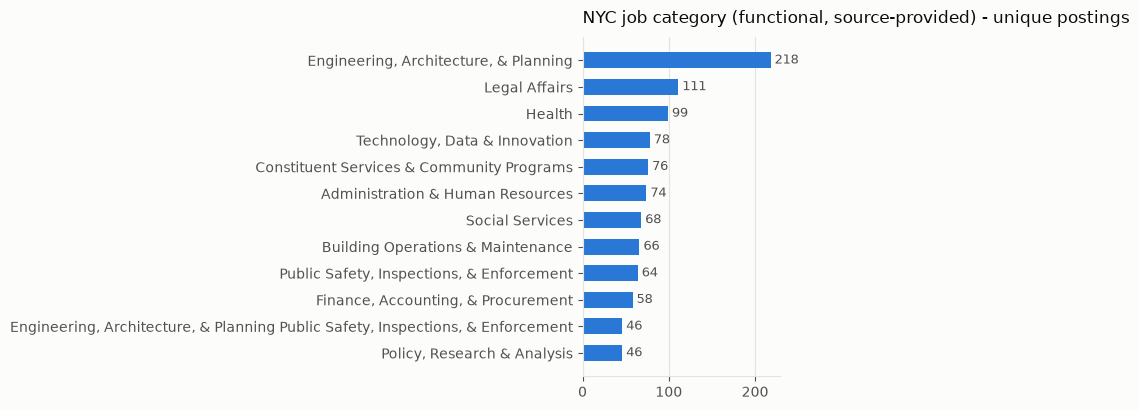

In [12]:
cat = q('''SELECT job_category_source, count(*) n FROM job_postings_unique WHERE source='nyc_jobs' GROUP BY 1 ORDER BY 2 DESC LIMIT 12''').iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 4.2)); ax.barh(cat.job_category_source.fillna('(missing)'), cat.n, color=BLUE, height=0.6)
for y, v in enumerate(cat.n): ax.text(v, y, f' {v}', va='center', color=INK2, fontsize=9)
style(ax, 'NYC job category (functional, source-provided) - unique postings'); plt.tight_layout(); plt.show()

## 10. Seniority
`seniority` = source value mapped to a common scale when available (`seniority_basis='source'`), otherwise a transparent title-keyword rule (`'title_rule'`), otherwise NULL. Raw source value is kept in `seniority_source`, rule output in `seniority_derived`.

In [13]:
q('''SELECT source, coalesce(seniority,'(unknown)') AS seniority, coalesce(seniority_basis,'none') AS basis, count(*) n FROM job_postings GROUP BY ALL ORDER BY source, n DESC''')

,source,seniority,basis,n
0,arbeitnow,experienced,source,761
1,arbeitnow,(unknown),none,645
2,arbeitnow,manager,title_rule,415
3,arbeitnow,senior,title_rule,355
4,arbeitnow,intern_student,source,268
5,arbeitnow,entry,source,104
6,arbeitnow,intern_student,title_rule,63
7,arbeitnow,entry,title_rule,48
8,arbeitnow,manager,source,38
9,arbeitnow,executive,title_rule,19


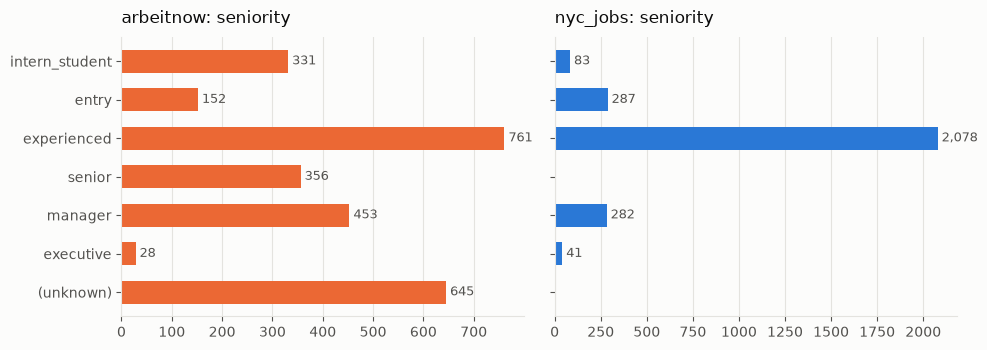

In [14]:
sen = q("SELECT source, coalesce(seniority,'(unknown)') AS s, count(*) n FROM job_postings GROUP BY ALL")
order = ['intern_student','entry','experienced','senior','manager','executive','(unknown)']
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for ax, (src, g) in zip(axes, sen.groupby('source')):
    g = g.set_index('s').reindex(order).fillna(0)
    ax.barh(order, g.n, color=SOURCE_COLORS.get(src, BLUE), height=0.6)
    for y, v in enumerate(g.n):
        if v: ax.text(v, y, f' {int(v):,}', va='center', color=INK2, fontsize=9)
    style(ax, f'{src}: seniority')
axes[0].invert_yaxis(); plt.tight_layout(); plt.show()

## 11. Description length (characters and words)

In [15]:
desc_stats(con)

,source,n,chars_mean,chars_median,chars_std,chars_min,chars_max,words_mean,words_median,words_std,words_min,words_p05,words_p25,words_p75,words_p95,words_max
0,arbeitnow,2726,4425.9,4188.5,1832.3,33,15798,618.3,575.5,278.5,6,248.0,425.0,770.8,1098.3,2229
1,nyc_jobs,2771,4165.0,3756.0,1922.4,651,14614,597.9,532.0,273.1,88,266.5,399.0,742.0,1143.0,1963
2,ALL,5497,4294.4,3977.0,1882.6,33,15798,608.0,557.0,276.0,6,255.0,407.0,759.0,1123.4,2229


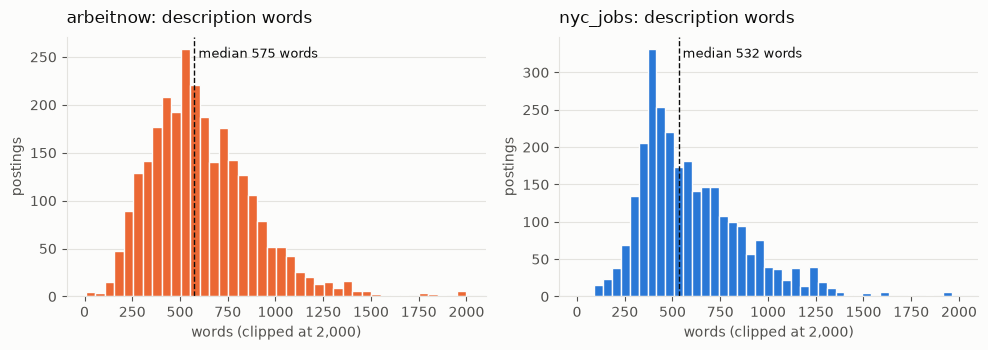

In [16]:
df = q('SELECT source, description_word_count w FROM job_postings WHERE description_word_count IS NOT NULL')
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharex=True)
for ax, (src, g) in zip(axes, df.groupby('source')):
    ax.hist(g.w.clip(upper=2000), bins=40, color=SOURCE_COLORS.get(src, BLUE), edgecolor='#fcfcfb', linewidth=1)
    ax.axvline(g.w.median(), color=INK, linewidth=1, linestyle='--')
    ax.text(g.w.median(), ax.get_ylim()[1]*0.92, f' median {int(g.w.median())} words', color=INK, fontsize=9)
    style(ax, f'{src}: description words', 'words (clipped at 2,000)', 'postings')
plt.tight_layout(); plt.show()

In [17]:
q('SELECT source, count(*) FILTER (WHERE description_word_count < 50) under_50_words, count(*) FILTER (WHERE description IS NULL) no_description, round(avg(posting_text_word_count),1) avg_full_text_words FROM job_postings GROUP BY 1')

,source,under_50_words,no_description,avg_full_text_words
0,arbeitnow,5,0,623.9
1,nyc_jobs,0,0,813.8


## 12. Language mix (langdetect, deterministic seed; ISO 639-1)

In [18]:
q('''SELECT coalesce(language,'(undetected)') AS language, source, count(*) n, round(avg(language_confidence),3) avg_conf FROM job_postings GROUP BY ALL ORDER BY n DESC''')

,language,source,n,avg_conf
0,en,nyc_jobs,2771,1.000
1,en,arbeitnow,1436,1.000
2,de,arbeitnow,1229,0.999
3,fr,arbeitnow,61,0.993


## 13. Geography
NYC `country`/`state` are derived from source scope (municipal employer); `city` is not parsed. Arbeitnow only provides `location_raw` - country is **not** inferred.

In [19]:
q('''SELECT source, location_raw, count(*) n FROM job_postings GROUP BY source, location_raw QUALIFY row_number() OVER (PARTITION BY source ORDER BY count(*) DESC) <= 8 ORDER BY source, n DESC''')

,source,location_raw,n
0,arbeitnow,Berlin,554
1,arbeitnow,Munich,201
2,arbeitnow,Hamburg,143
3,arbeitnow,München,135
4,arbeitnow,Germany,114
5,arbeitnow,NaN,57
6,arbeitnow,Remote,48
7,arbeitnow,Köln,48
8,nyc_jobs,30-30 Thomson Ave L I City Qns,341
9,nyc_jobs,42-09 28th Street,204


In [20]:
q('SELECT source, count(DISTINCT location_raw) distinct_locations, count(*) FILTER (WHERE remote_flag) remote_postings FROM job_postings GROUP BY 1')

,source,distinct_locations,remote_postings
0,nyc_jobs,211,0
1,arbeitnow,478,153


## 14. Date coverage

In [21]:
q('SELECT source, min(date_posted) first_posted, max(date_posted) last_posted, median(date_posted) median_posted, count(date_posted) dated, min(date_collected) collected FROM job_postings GROUP BY 1')

,source,first_posted,last_posted,median_posted,dated,collected
0,arbeitnow,2026-09-20,2026-09-25,2026-09-23,2726,2026-09-25
1,nyc_jobs,2025-09-25,2026-09-21,2026-08-25,2771,2026-09-25


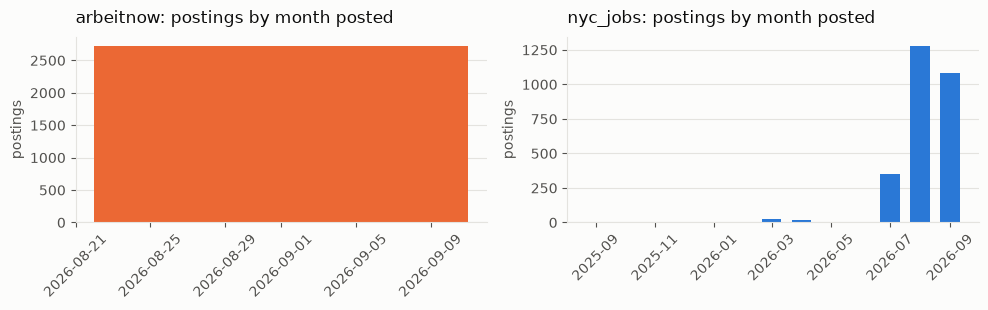

In [22]:
dd = q("SELECT source, date_trunc('month', date_posted) m, count(*) n FROM job_postings WHERE date_posted IS NOT NULL GROUP BY ALL ORDER BY m")
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for ax, (src, g) in zip(axes, dd.groupby('source')):
    ax.bar(g.m, g.n, width=20, color=SOURCE_COLORS.get(src, BLUE)); style(ax, f'{src}: postings by month posted', '', 'postings')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

## 15. Source comparison

In [23]:
q('''SELECT source, count(*) postings, count(DISTINCT company_name) employers,
       round(100*avg((salary_min IS NOT NULL)::INT),1) pct_salary, round(100*avg((requirements IS NOT NULL)::INT),1) pct_requirements,
       round(100*avg((seniority_basis='source')::INT),1) pct_seniority_from_source, median(description_word_count) median_words,
       string_agg(DISTINCT language, ',') languages FROM job_postings GROUP BY 1''')

,source,postings,employers,pct_salary,pct_requirements,pct_seniority_from_source,median_words,languages
0,arbeitnow,2726,1133,0.0,0.0,56.8,575.5,"de,fr,en"
1,nyc_jobs,2771,58,100.0,98.7,100.0,532.0,en


In [24]:
q("SELECT salary_period, salary_currency, count(*) n, median(salary_min) median_min, median(salary_max) median_max FROM job_postings WHERE salary_min IS NOT NULL GROUP BY ALL ORDER BY n DESC")

,salary_period,salary_currency,n,median_min,median_max
0,annual,USD,2556,70983.5000,95611.00
1,hourly,USD,189,23.1461,25.00
2,daily,USD,26,411.8100,411.81


## 16. O\*NET reference tables
O\*NET 31.0 restructured the content model: *Skills* are now **Essential Skills (2.A)** + **Transferable Skills (2.B)** (both loaded into `onet_skills`, distinguished by `source_file`), and *Technology Skills* became **Software Skills (2.E)** (`onet_technology_skills`).

In [25]:
q("SELECT table_name, files, row_count, status FROM reference_load_report WHERE table_name LIKE 'onet%'")

,table_name,files,row_count,status
0,onet_occupations,data/reference/onet/extracted/31.0/db_31_0_csv/occupation_data.csv,1016,LOADED
1,onet_tasks,data/reference/onet/extracted/31.0/db_31_0_csv/task_statements.csv,18838,LOADED
2,onet_skills,data/reference/onet/extracted/31.0/db_31_0_csv/essential_skills.csv; data/re...,63700,LOADED
3,onet_knowledge,data/reference/onet/extracted/31.0/db_31_0_csv/knowledge.csv,60060,LOADED
4,onet_abilities,data/reference/onet/extracted/31.0/db_31_0_csv/abilities.csv,94640,LOADED
5,onet_work_activities,data/reference/onet/extracted/31.0/db_31_0_csv/work_activities.csv,74702,LOADED
6,onet_technology_skills,data/reference/onet/extracted/31.0/db_31_0_csv/software_skills.csv,31821,LOADED
7,onet_content_model_reference,data/reference/onet/extracted/31.0/db_31_0_csv/content_model_reference.csv,3006,LOADED
8,onet_scales_reference,data/reference/onet/extracted/31.0/db_31_0_csv/scales_reference.csv,33,LOADED
9,onet_job_zones,data/reference/onet/extracted/31.0/db_31_0_csv/job_zones.csv,923,LOADED


In [26]:
q('SELECT source_file, count(*) AS n_rows, count(DISTINCT element_id) elements, count(DISTINCT onetsoc_code) occupations FROM onet_skills GROUP BY 1')

,source_file,n_rows,elements,occupations
0,transferable_skills,45500,25,910
1,essential_skills,18200,10,910


## 17. ESCO reference tables

In [27]:
q("SELECT dataset_name, version, status, final_or_temporary FROM source_metadata WHERE dataset_name LIKE 'esco%'")

,dataset_name,version,status,final_or_temporary
0,esco_api_fallback,v1.2.1,OK (temporary API fallback),TEMPORARY - replace with official ESCO CSV package (manual download)
1,esco_status,v1.2.1,ESCO_STATUS = MANUAL_DOWNLOAD_REQUIRED (official ZIP); TEMPORARY_API_FALLBAC...,api_fallback


In [28]:
q("SELECT table_name, files, row_count, status FROM reference_load_report WHERE table_name LIKE 'esco%'")

,table_name,files,row_count,status
0,esco_occupations,data/reference/esco/extracted/api_v1.2.1/occupations.csv,3039,LOADED
1,esco_skills,data/reference/esco/extracted/api_v1.2.1/skills.csv,13939,LOADED
2,esco_occupation_skill_relations,data/reference/esco/extracted/api_v1.2.1/occupation_skill_relations.csv,126051,LOADED
3,esco_occupation_hierarchy,data/reference/esco/extracted/api_v1.2.1/occupation_hierarchy.csv,3039,LOADED
4,esco_skill_hierarchy,data/reference/esco/extracted/api_v1.2.1/skill_hierarchy.csv,20183,LOADED


## 18. Data-quality findings (computed)

In [29]:
f = []
c = counts.iloc[0]
f.append(f"{int(c.duplicate_count):,} of {int(c.canonical_postings):,} canonical postings ({c.duplicate_pct}%) are normalized duplicates.")
r = q("SELECT source, sum(is_normalized_duplicate::INT) d, count(*) n FROM job_postings GROUP BY 1")
for x in r.itertuples(): f.append(f"{x.source}: {int(x.d):,}/{x.n:,} duplicates ({100*x.d/x.n:.1f}%).")
f.append(f"{int(c.raw_postings - c.canonical_postings)} raw records repeated an existing source ID in the same snapshot and were collapsed.")
m = missingness(con)
f.append('Fields 100% NULL in every source: ' + ', '.join(m.index[(m == 1).all(axis=1)]))
s = q("SELECT count(*) n FROM job_postings WHERE seniority IS NULL").n[0]
f.append(f"{s:,} postings have no seniority from source or title rule.")
sh = q("SELECT count(*) n FROM job_postings WHERE coalesce(description_word_count,0) < 50").n[0]
f.append(f"{sh:,} postings have a description under 50 words.")
nl = q("SELECT count(*) n FROM job_postings WHERE language IS NOT NULL AND language NOT IN ('en','de')").n[0]
f.append(f"{nl:,} postings detected in a language other than en/de.")
for x in f: print('-', x)

- 1,468 of 5,497 canonical postings (26.71%) are normalized duplicates.
- arbeitnow: 101/2,726 duplicates (3.7%).
- nyc_jobs: 1,367/2,771 duplicates (49.3%).
- 98 raw records repeated an existing source ID in the same snapshot and were collapsed.
- Fields 100% NULL in every source: industry, city, responsibilities
- 645 postings have no seniority from source or title rule.
- 5 postings have a description under 50 words.
- 61 postings detected in a language other than en/de.


## 19. Limitations
* Both job sources are **temporary bootstrap sources** - instructor/team approval required before final corpus selection.
* NYC Jobs is **public-sector only and one city**; Arbeitnow is a **Germany-centric aggregator**. Neither is representative of the US or EU labour market.
* Snapshots are **point-in-time** (currently open postings), not a historical panel.
* USAJOBS / Adzuna were not pulled (no credentials configured); see `docs/USAJOBS_API_SETUP.md`.
* No source supplies an employer **industry**; NYC `job_category` is functional, Arbeitnow `tags` are free-form.
* Seniority for a large share of Arbeitnow postings (see section 10) comes from a keyword rule on titles (labelled `title_rule`), which is approximate.
* ESCO is loaded from the official ESCO **Web Services API** (v1.2.1) as a temporary fallback until the official CSV package is downloaded manually.
* Language detection (langdetect) is probabilistic; short or mixed-language postings can be misclassified.

## 20. Recommendations for Sprint 2
1. Get instructor approval for the corpus; add **USAJOBS** credentials to broaden US public-sector coverage, and consider Adzuna for private sector.
2. Download the official **ESCO v1.2.1 CSV** package (see `docs/ESCO_MANUAL_DOWNLOAD_REQUIRED.md`) - the pipeline swaps it in automatically.
3. Use `job_postings_unique` (one row per duplicate group) as the default extraction input to avoid double counting.
4. Both teams key everything on `posting_id`; the task team extracts from `description` (+`requirements`), the skill team from `posting_text`.
5. Decide language policy: English-only for the first extraction pass, or translate/handle German postings explicitly.

In [30]:
con.close()